[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/cdg-ime/blob/main/PreProcessamento.ipynb)

# Ciência de Dados Geoespaciais - Pré-Processamento

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Identificar problemas comuns nos dados vetoriais;
2. Identificar problemas comuns nos dados raster;
3. Aplicar métodos de limpeza de dados;
4. Aplicar métodos de seleção de dados;
5. Aplicar métodos de completamento de dados.


## O Contexto

Após a **prospecção**, raramente os dados chegam prontos para análise. Na prática, estima-se que [60–80% do tempo de um cientista de dados é gasto limpando e preparando os dados (pré-processamento)](https://www.linkedin.com/pulse/quanto-tempo-um-analista-de-dados-passa-realmente-rafael-pacheco-4oj5f/).

Prospecção $\rightarrow$ **Pré-Processamento** $\rightarrow$ Exploração $\rightarrow$ Modelagem $\rightarrow$ Comunicação 

## 1. Identificar problemas comuns nos dados vetoriais

**Dataset de referência**: Usaremos um dataset vetorial sintético (`postos_pluviometricos.gpkg`) do estado do Rio de Janeiro, propositalmente com problemas comuns do mundo real.

In [91]:
import pandas as pd
import geopandas as gpd

# Dataset sintético: postos pluviométricos do RJ
dados_brutos = {
    'id'           : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'nome'         : ['Posto A', 'Posto B', 'Posto C', 'Posto D', 'posto a',
                       'Posto F', 'Posto G', 'Posto H', 'Posto I', 'Posto J', 
                       'Posto K', 'Posto B'],                                        # Posto duplicado
    'municipio'    : ['Niterói', 'Rio de Janeiro', 'Petrópolis', 'Angra dos Reis',
                       'Niterói', 'Volta Redonda', None, 'Campos', 'Resende', 
                       'Macaé', 'Cabo Frio', 'Rio de Janeiro'],                      # Cidade desconhecida
    'latitude'     : [-22.88, -22.90, -22.51, -23.01, -22.88, -22.52,
                      -22.75, -21.75, -22.47, -22.38, -22.88, -22.90],
    'longitude'    : [-43.10, -43.17, -43.18, -44.32, -43.10, -44.08,
                      -250.0, -41.33, -44.45, -41.79, -42.02, -43.17],   # longitude inválida
    'precip_jan_mm': [120.5, 135.0, 98.3,  None,  120.5, 88.7, 
                       77.2, 200.0,  61.4,  110.2, 95.8, 135.0],         # precipitação desconhecida
    'precip_fev_mm': [110.2, 142.1, 91.7,  88.0,  110.2, 80.1,
                       70.5,  9999.0, 58.2,  105.3, 91.1, 142.1],         # 9999 = valor sentinela
    'ativo'        : [True, True, True, True, True, True, True, False, True,
                      True, True, True]
}

df = pd.DataFrame(dados_brutos)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
gdf.to_file("postos_pluviometricos.gpkg", driver="GPKG")

df.head(12)[["nome", "municipio", "latitude", "longitude", "precip_jan_mm", "precip_fev_mm", "ativo"]]

,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,ativo
0,Posto A,Niterói,-22.88,-43.10,120.5,110.2,True
1,Posto B,Rio de Janeiro,-22.90,-43.17,135.0,142.1,True
2,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,True
3,Posto D,Angra dos Reis,-23.01,-44.32,NaN,88.0,True
4,posto a,Niterói,-22.88,-43.10,120.5,110.2,True
5,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,True
6,Posto G,NaN,-22.75,-250.00,77.2,70.5,True
7,Posto H,Campos,-21.75,-41.33,200.0,9999.0,False
8,Posto I,Resende,-22.47,-44.45,61.4,58.2,True
9,Posto J,Macaé,-22.38,-41.79,110.2,105.3,True


### **1.1 Categorias de problemas nos dados vetoriais**

| Categoria | Problema | Exemplo no dataset |
|-----------|----------|--------------------|
| **Completude** | Valores ausentes (`NaN`) | `municipio` do Posto G|
| **Consistência** | Duplicatas | Posto B (mesmas coordendas) |
| **Validade** | Valores fora do domínio¹ | `longitude = -250.0` (impossível) |
| **Validade** | Valores sentinela | `precip_fev_mm = 9999` (código de erro legado) |
| **Relevância** | Registros inativos | `ativo = False` no Posto H |
| **Padronização** | Inconsistência de grafia | `'posto a'` vs `'Posto A'` |

(1): **Validade geométrica:** Inclui a análise da estruturas geométricas fora do domínio, ou seja, das regras do contexto semântico em que o dado se encontra. <br>
**Por exemplo:** Autointerseções, nós duplicados, sobreposições entre poligonos, lacunas entre polígonos, etc ...

### **1.2 Ferramentas de diagnóstico**

[Data type objects (dtype)](https://numpy.org/doc/stable/reference/arrays.dtypes.html): Descreve como os bytes correspodentes ao dado devem ser interpretados. 

In [92]:
# Tipos de dados
print("=" * 50)
print("TIPOS DE DADOS")
print("=" * 50)
print(df.dtypes)


TIPOS DE DADOS
id                 int64
nome                 str
municipio            str
latitude         float64
longitude        float64
precip_jan_mm    float64
precip_fev_mm    float64
ativo               bool
dtype: object


### **1.2 Ferramentas de diagnóstico**

[pandas.DataFrame.describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html): Gera estatísticas descritivas que incluem o centro tendência, dispersão e formato de um Distribuição do conjunto de dados, excluindo valores `NaN`.

In [93]:
# Visão geral
print("\n" + "=" * 50)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 50)
df.describe()


ESTATÍSTICAS DESCRITIVAS


,id,latitude,longitude,precip_jan_mm,precip_fev_mm
count,12.000000,12.000000,12.000000,11.000000,12.000000
mean,5.500000,-22.652500,-60.309167,112.963636,924.041667
std,3.605551,0.353557,59.744949,37.018840,2857.983262
min,0.000000,-23.010000,-250.000000,61.400000,58.200000
25%,2.750000,-22.885000,-44.140000,92.250000,86.025000
50%,5.500000,-22.815000,-43.170000,110.200000,98.500000
75%,8.250000,-22.500000,-42.830000,127.750000,118.175000
max,11.000000,-21.750000,-41.330000,200.000000,9999.000000


### **1.2 Ferramentas de diagnóstico**

[ogrinfo](https://gdal.org/en/stable/programs/ogrinfo.html): Lista informações sobre uma fonte de dados suportada pela OGR. Com instruções SQL, também é possível editar dados.

In [94]:
# ogrinfo
qgis_gdal_path = 'C:/Program Files/QGIS 3.44.8/bin' # 'ajustar
!"{qgis_gdal_path}/ogrinfo.exe" -so postos_pluviometricos.gpkg postos_pluviometricos

O sistema n�o pode encontrar o caminho especificado.


### **1.3 Categoria completude**

In [95]:
# Valores ausentes
ausentes = df.isnull().sum()
pct = (ausentes / len(df) * 100).round(1)

auditoria = pd.DataFrame({
    'Nulos'     : ausentes,
    'Percentual': pct
}).query('Nulos > 0')

print("Colunas com valores ausentes:")
print(auditoria)

Colunas com valores ausentes:
               Nulos  Percentual
municipio          1         8.3
precip_jan_mm      1         8.3


### **1.4 Categoria consistência**

In [96]:
# Verificação de duplicatas
print("Duplicatas por coordenada:")
print(df[df.duplicated(subset=['latitude','longitude'], keep=False)]
      [['id','nome','latitude','longitude']])

Duplicatas por coordenada:
    id     nome  latitude  longitude
0    0  Posto A    -22.88     -43.10
1    1  Posto B    -22.90     -43.17
4    4  posto a    -22.88     -43.10
11  11  Posto B    -22.90     -43.17


### **1.5 Categoria validade**

In [97]:
# Verificação de domínio (regras de negócio)
print("Coordenadas fora do domínio válido (lat: -90/90, lon: -180/180):")
invalidos_coord = df[
    (df['latitude'].abs()  > 90)  |
    (df['longitude'].abs() > 180)
]
print(invalidos_coord[['id','nome','latitude','longitude']])

print("\nValores sentinela (9999):")
print(df[df[['precip_jan_mm','precip_fev_mm']].ge(9000).any(axis=1)]
      [['id','nome','precip_jan_mm','precip_fev_mm']])

Coordenadas fora do domínio válido (lat: -90/90, lon: -180/180):
   id     nome  latitude  longitude
6   6  Posto G    -22.75     -250.0

Valores sentinela (9999):
   id     nome  precip_jan_mm  precip_fev_mm
7   7  Posto H          200.0         9999.0


### **1.6 Categoria relevância**

In [98]:
# Verificação de valores sem confiabilidade (ex: estações inativas)
print("Estações inativas:")
print(df[df.ativo == False][['id','nome','latitude','longitude', 'ativo']])

Estações inativas:
   id     nome  latitude  longitude  ativo
7   7  Posto H    -21.75     -41.33  False


### **1.7 Categoria padronização**

In [99]:
# Verificação de erros de inserção de dados textuais (falta de padronização)
show_cols = ['id','nome','latitude','longitude', 'ativo']
print("Nomes fora do padrão:")
print(df[~df['nome'].str.contains(r'Posto [A-Z\s]', regex=True)][show_cols])

Nomes fora do padrão:
   id     nome  latitude  longitude  ativo
4   4  posto a    -22.88      -43.1   True


### **1.8 Visualização dos problemas (big picture)**

Vamos criar uma imagem (matriz) onde os valores representam o problema do dado.

**1º Passo**: O formato da tabela é o formato da imagem

In [100]:
nulos = df.isnull()
colunas = df.columns.tolist()
nulos

,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,ativo
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,True,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


**2º Passo**: converter de booleano para inteiro e definir valor=1 caso nulo

In [101]:
nulos = nulos.values.astype(int)
nulos

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**3º Passo**: definir valor=2 caso duplicatas

In [102]:
import numpy as np

dup_df = df[df.duplicated(subset=['latitude','longitude'], keep=False)].copy()
grupos = list(dup_df.groupby(['latitude', 'longitude'])
              .apply(lambda g: list(g.index)))
# grupos = [[1, 11], [0, 4]]

original, repetidos = [el[0] for el in grupos], [el[1:] for el in grupos]

duplicatas = np.zeros(nulos.shape, dtype=int)
duplicatas[repetidos] = 2
duplicatas

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2]])

**4º Passo**: definir valor=3 caso inválido

In [103]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Coordenadas inválidas
condicao = df['latitude'].abs()  > 90
df_bool.loc[condicao, ['latitude']] = True
condicao = df['longitude'].abs() > 180
df_bool.loc[condicao, ['longitude']] = True

# Valores sentinela (9999)
condicao = df[['precip_jan_mm']].ge(9000).any(axis=1)
df_bool.loc[condicao, ['precip_jan_mm']] = True
condicao = df[['precip_fev_mm']].ge(9000).any(axis=1)
df_bool.loc[condicao, ['precip_fev_mm']] = True

invalidos = 3 * df_bool.values.astype(int)
invalidos

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**5º Passo**: definir valor=4 caso irrelevante

In [104]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Postos inativos
condicao = df['ativo'] == False
df_bool.loc[condicao, ['ativo']] = True

irrelevantes = 4 * df_bool.values.astype(int)
irrelevantes

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 4],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**6º Passo**: definir valor=5 caso despadronizado

In [105]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Nome com a a letra não maiúscuala
condicao = ~df['nome'].str.contains(r'Posto [A-Z\s]', regex=True)
df_bool.loc[condicao, ['nome']] = True

despadronizado = 5 * df_bool.values.astype(int)
despadronizado

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 5, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**7º Passo**: Juntar tudo e definir valor=6 para múltiplos problemas 

In [106]:
# Sobrepor matrizes: máximo em cada posição (prioridade de problema)
mascara = np.maximum.reduce([nulos, duplicatas, invalidos, irrelevantes, despadronizado])
mascara

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [2, 5, 2, 2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 3, 4],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2]])

**8º Passo**: Planejar as cores

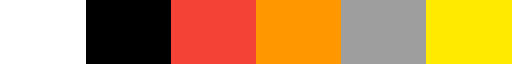

In [107]:
import matplotlib.colors as mcolors

N_cores = mascara.max()+1
colors = {
    "Sem problemas": "#ffffff",      # Branco - nenhum problema
    "Nulos": "#000000",              # Preto - dados faltando (recuperáveis)
    "Duplicatas": "#f44336",         # Vermelho vivo - erro crítico de integridade
    "Inválidos": "#ff9800",          # Laranja - aviso, fora de domínio
    "Irrelevantes": "#9e9e9e",       # Cinza médio - sem relevância
    "Despadronizados": "#ffea00"     # Amarelo - atenção, inconsistência
}
cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", 
                                                 list(colors.values()), 
                                                 N=N_cores)
cmap

**9º Passo**: Plot com mapa de cores

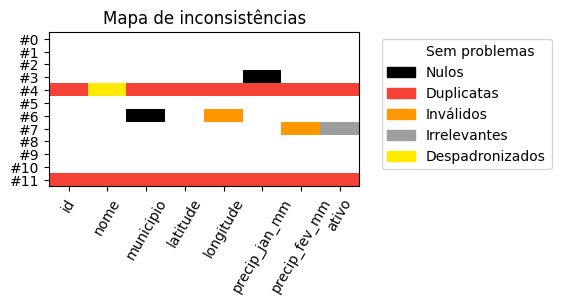

In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 2))
ax.imshow(mascara, aspect='auto', cmap=cmap)
ax.set_yticks(range(len(df)))
ax.set_yticklabels([f"#{i}" for i in df['id']])
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=60)
ax.set_title("Mapa de inconsistências")
plt.legend(handles=[plt.Rectangle((0,0),1,1, color=colors[cat]) for cat in colors], 
           labels=list(colors.keys()), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **1.9 Validação geométrica**

<img src="media/imgs/geometry_checker_scheme.png" width=600>

Verificações suportdas pelo plugin do QGIS [Verificador de Geometria](https://docs.qgis.org/3.44/pt_BR/docs/user_manual/plugins/core_plugins/plugins_geometry_checker.html)

### **1.9 A validação geométrica**

A validação geométrica limpa os dados fora das regras topológicas do contexto. Imagine os seguintes problemas:

| Validação            | Tipo           | O que detecta | Possível aplicação          |
| -------------------------------- | -------------- | --------------| ---------------------------|
| **Self-intersection** | Linha/Polígono | Geometria cruza a si mesma                 | Correção de Limites administrativos     |
| **Duplicate nodes**  | Linha/Polígono | Vértices consecutivos na mesma posição      | Otimização dos algoritimos subsequentes |
| **Duplicate geommetries**  | Todos    | Geometrias na mesma posição                 | Otimização dos algoritimos subsequentes |
| **Spike**            | Linha/Polígono | Pontas estreitas geradas por erro de edição | Limpeza cartográfica                         |
| **Small area / Sliver** | Polígono    | Polígonos muito pequenos e indesejados      | Limpeza cartográfica                         |


### **1.9 A validação geométrica**

Imagine os seguintes problemas:

| Validação            | Tipo           | O que detecta | Possível aplicação          |
| -------------------------------- | -------------- | --------------| ---------------------------|
| **Gap**              | Polígono       | Lacunas entre polígonos adjacentes          | Cobertura contínua (cadastro, zoneamento)    |
| **Overlap**          | Polígono       | Sobreposição entre feições                  | Correção de Limites administrativos      |
| **Multipart geometry** | Todos        | Feição composta por partes desconectadas    | Quando apenas feições simples são permitidas |
| **Line overlap**     | Linha          | Trechos de linhas sobrepostos               | Redes lineares e limites                     |

### **1.10 Ferramentas de validação geométrica**

**qgis_process native:checkgeometry** 

```
qgis_bin_path = 'C:/Program Files/QGIS 3.44.8/bin' # 'ajustar
!"{qgis_bin_path}/qgis_process-qgis-ltr.bat" list
```

```
...
QGIS (native c++)
...
	native:checkgeometryangle			Small angles
	native:checkgeometryarea			Small polygons
	native:checkgeometrycontained			Features inside polygon
	native:checkgeometrydangle			Dangle-end lines
	native:checkgeometrydegeneratepolygon		Degenerate polygons
	native:checkgeometryduplicate			Duplicated geometries
	native:checkgeometryduplicatenodes		Duplicated vertices
	native:checkgeometryfollowboundaries		Polygons exceeding boundaries
	native:checkgeometrygap				Small gaps
	native:checkgeometryhole			Holes
	native:checkgeometrylineintersection		Lines intersecting each other
	native:checkgeometrylinelayerintersection	Lines intersecting other layer
	native:checkgeometrymissingvertex		Missing vertices along borders
	native:checkgeometrymultipart			Strictly multipart
	native:checkgeometryoverlap			Overlaps
	native:checkgeometrypointcoveredbyline		Points outside lines
	native:checkgeometrypointinpolygon		Points outside polygons
	native:checkgeometrysegmentlength		Small segments
	native:checkgeometryselfcontact			Self-contacts
	native:checkgeometryselfintersection		Self-intersections
	native:checkgeometrysliverpolygon		Sliver polygons
	native:checkvalidity				Check validity
...
```

### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

<img src="media/imgs/geometry_checker_dialog.png" width=700>

Acesso ao Plugin do QGIS [Verificador de Geometria](https://docs.qgis.org/3.44/pt_BR/docs/user_manual/plugins/core_plugins/plugins_geometry_checker.html) via GUI

### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

In [109]:
qgis_bin_path = 'C:/Program Files/QGIS 3.44.8/bin' # 'ajustar
!"{qgis_bin_path}/qgis_process-qgis-ltr.bat" help native:checkgeometryduplicate

O sistema n�o pode encontrar o caminho especificado.


### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

In [110]:
# Evitar erros de GUI
import os
os.environ['QT_QPA_PLATFORM'] = 'offscreen'  # Evitar erros de GUI

# Cria um projeto QGIS temporário para o processamento.
# requisito do native:checkgeometryduplicate
with open("temp.qgs", "w") as f:
    f.write(f"""<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version="3.44"/>""")

# Verificação de geometrias duplicadas
!"{qgis_bin_path}/qgis_process-qgis-ltr.bat" run native:checkgeometryduplicate \
  --INPUT="postos_pluviometricos.gpkg|layername=postos_pluviometricos" \
  --UNIQUE_ID=id \
  --ERRORS=erros_geometrias_duplicadas.gpkg \
  --PROJECT_PATH=temp.qgs

O sistema n�o pode encontrar o caminho especificado.


## 2. Identificar problemas comuns nos dados raster

### **2.1 Categorias de problemas nos dados raster**

| Categoria              | Problema                             | Consequência                                 |
| ---------------------- | ------------------------------------ | -------------------------------------------- |
| **SRC / CRS**          | CRS ausente ou incorreto             | Camadas não se alinham, erros de localização |
| **NoData**             | Valor NoData não definido ou coincide com valor real | Pixels inválidos entram nos cálculos |
| **Histograma**         | Outliers extremos                    | Contraste ruim e visualização inadequada     |
| **Resolução**          | Pixels com tamanhos diferentes       | Comparações e operações inconsistentes       |
| **Tipo de dado**       | Conversão Float → Integer            | Perda de precisão                            |
| **Compressão**         | Compressão com perdas                | Artefatos e degradação da qualidade          |
| **Metadados**          | Metadados ausentes ou incorretos     | Perda de informação e possivelmente de continuidade de processamento |


### **2.2 Categoria SRC e metadados**

**Dataset de referência**: Usaremos também um dataset raster do jardim botânico propositalmente com problemas comuns do mundo real.

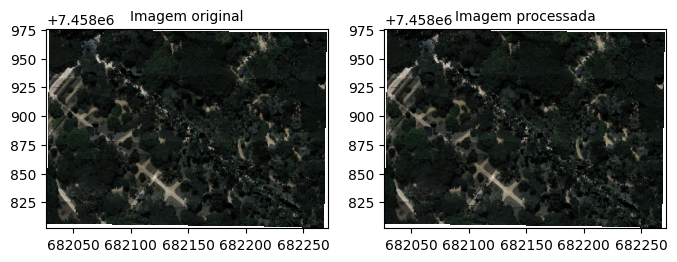

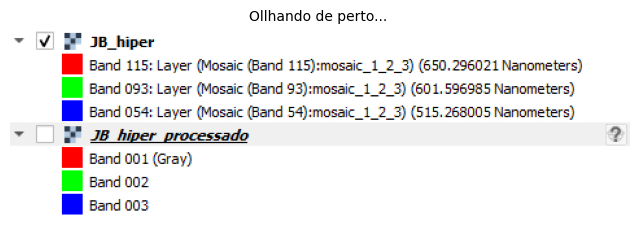

In [111]:
import os
import gdown
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

if not os.path.exists("./JB_hiper.tif"):
    gdown.download( id= "1G7tuNW-r0uxZ25OR66MZ9su4fMk8cGKW", output="./JB_hiper.tif", quiet=True)

# qgis_gdal_path = 'C:/Program Files/QGIS 3.40.4/bin' # 'ajustar
# !"{qgis_gdal_path}/gdalinfo.exe" JB_hiper.tif

src = rasterio.open('JB_hiper.tif')
# TODO: processamento
processed_data = src.read() 
rgb_src = src.read([115, 93, 54])

with rasterio.open('JB_hiper_processado.tif', 
                   'w', 
                   driver='GTiff', 
                   # crs=src.crs, # bug embutido
                   height=src.height, 
                   width=src.width,
                   nodata=-9999, #src.nodata, # bug embutido
                   count=src.count, 
                   dtype=src.read().dtype, 
                   transform=src.transform
                   ) as dst:
    
    dst.write(processed_data)

fig, ax = plt.subplots(1, 2 ,figsize=(8, 8))

processada = rasterio.open('JB_hiper_processado.tif')
rgb_processada = processada.read([115, 93, 54])
ax[0].set_title("Imagem original", fontsize=10)
ax[1].set_title("Imagem processada", fontsize=10)
show(rgb_src, ax=ax[0], transform=src.transform) 
show(rgb_processada, ax=ax[1], transform=processada.transform) 
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("Ollhando de perto... ", fontsize=10)
ax.imshow(plt.imread("media/imgs/camadas.png"))

ax.set_axis_off()
plt.show()

### **2.2 Categoria SRC e metadados**

In [112]:
qgis_bin_path = 'C:/Program Files/QGIS 3.40.4/bin' # 'ajustar

In [113]:
!"{qgis_bin_path}/gdalinfo.exe" JB_hiper.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper.tif
Size is 613, 434
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 23S",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]],
    CONVERSION["Transverse Mercator",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre

Warning 1: PROJ: proj_create_from_database: Open of d:\Diego\SE6\Disciplinas\Ci�ncia de dados geoespaciais 2026.2\git2\cdg-ime\.venv\Lib\site-packages\osgeo\data\proj\proj.db failed
Warning 1: The definition of projected CRS EPSG:32723 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


In [114]:
!"{qgis_bin_path}/gdalinfo.exe" JB_hiper_processado.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper_processado.tif
Size is 613, 434
Origin = (682026.399999982211739,7458976.000003093853593)
Pixel Size = (0.399999999999990,-0.400000000000166)
Image Structure Metadata:
  INTERLEAVE=PIXEL
Corner Coordinates:
Upper Left  (  682026.400, 7458976.000) 
Lower Left  (  682026.400, 7458802.400) 
Upper Right (  682271.600, 7458976.000) 
Lower Right (  682271.600, 7458802.400) 
Center      (  682149.000, 7458889.200) 
Band 1 Block=613x1 Type=Float32, ColorInterp=Gray
  NoData Value=-9999
Band 2 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 3 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 4 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 5 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 6 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 7 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 8 Block=613x1 Type

### **2.2 Categoria SRC e metadados**

A verdade é que se após um processamento os metadados da imagem original se perderam. Na maioria das vezes, o mais fácil é *refazer o processamento da imagem corretamente*. 

Se o usuário ainda possui o raster original, pode-se **transplantar os metadados raster**:

In [115]:
# O dado matricial em si vem do arquivo defeituso em metadados
processado = rasterio.open('JB_hiper_processado.tif')
data = processado.read()

# Os metadados vem do arquivo original não processado
src = rasterio.open('JB_hiper.tif')
profile = src.profile.copy()
file_tags = src.tags()
band_descriptions = src.descriptions
nodata_value = src.nodata

# Atenção na gravação: usar o profile do arquivo original, 
# mas os dados do processado
with rasterio.open("JB_hiper_processado2.tif", "w", **profile) as dst:
        #  Write the image data
        dst.write(data)
        
        # Copy file-level metadata tags
        if file_tags:
            dst.update_tags(**file_tags)
            
        # Copy band-level descriptions (names)
        for band_idx, desc in enumerate(band_descriptions, start=1):
            if desc:
                dst.set_band_description(band_idx, desc.split("mosaic_1_2_3) ")[-1])
                
        # Ensure NoData value is preserved explicitly if needed
        if nodata_value is not None:
            dst.nodata = nodata_value

In [116]:
!"{qgis_bin_path}/gdalinfo.exe" JB_hiper_processado2.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper_processado2.tif
Size is 613, 434
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 23S",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]],
    CONVERSION["Transverse Mercator",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGT

Warning 1: PROJ: proj_create_from_database: Open of d:\Diego\SE6\Disciplinas\Ci�ncia de dados geoespaciais 2026.2\git2\cdg-ime\.venv\Lib\site-packages\osgeo\data\proj\proj.db failed
Warning 1: The definition of projected CRS EPSG:32723 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


### **2.3 Categoria histograma**

**Dataset de referência**: Usaremos o dataset raster RADAR banda C da missão Sentinel 1, cujo download foi feito via catalogação STAC.

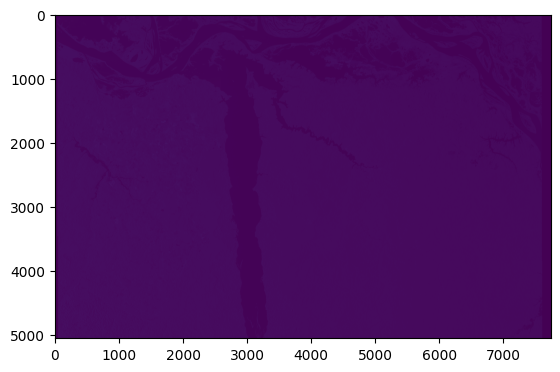

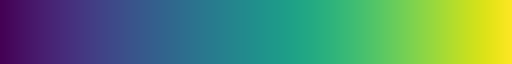

In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

path = "S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/" \
       "S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/" \
       "measurement/" \
       "s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff"

dataset = rasterio.open(f'/vsizip/{path}')


# resample data to not overload memory when showing
downscale_factor = 0.3
data = dataset.read(
    out_shape=(
        dataset.count,
        int(dataset.height * downscale_factor),
        int(dataset.width * downscale_factor)
    ),
    resampling=Resampling.bilinear
    )

ax = show(data, transform=dataset.transform, cmap='viridis')
plt.show()
display(plt.get_cmap('viridis'))
plt.show()

### **2.3 Categoria histograma**
 
**Histograma**

Muito escuro? Uma dica é checar o histograma e encontrar os valores menos comuns de pixels e cortá-los da plotagem.

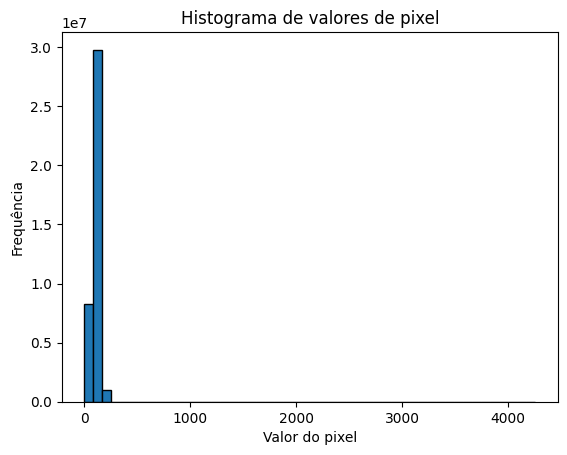

In [118]:
import numpy as np

frequencies, bin_edges = np.histogram(data, bins=50)
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(frequencies))]
bin_widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(frequencies))]

# Plot as a histogram-like bar chart
plt.bar(bin_centers, frequencies, width=bin_widths, align='center', edgecolor='black')
plt.xlabel('Valor do pixel')
plt.ylabel('Frequência')
plt.title('Histograma de valores de pixel')
plt.show()

**Histograma**

Percentis 2% e 98%: 0.00, 174.00


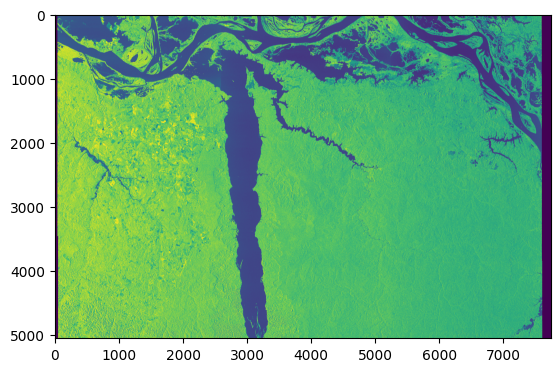

In [126]:
p2, p98 = np.nanpercentile(data, [2, 98])
print(f"Percentis 2% e 98%: {p2:.2f}, {p98:.2f}")
ax = show(data, cmap='viridis', percent_range=(2, 98), transform=dataset.transform,)

### **2.4 Categoria SRC**

O SRC e a matriz de transformação do referencial matricial (col ,lin) para o SRC geográfico (lat, lon) estão **funcionando no QGIS mas quebradas pelo rasterio**

<img src="media/imgs/qgis-radar.png">

In [120]:
print("Transformação georreferenciada:\n", dataset.transform)
print("Sistema de referência de coordenadas (CRS):", dataset.crs)

Transformação georreferenciada:
 | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Sistema de referência de coordenadas (CRS): None


### **2.4 Categoria SRC**

**SRC definido através de pontos de controle**

In [121]:
qgis_bin_path = 'C:/Program Files/QGIS 3.40.4/bin' # 'ajustar
!"{qgis_bin_path}/gdalinfo.exe" /vsizip/{path}

Driver: GTiff/GeoTIFF
Files: /vsizip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/measurement/s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff
Size is 25803, 16828
GCP Projection = 
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1,
                ID["EPSG",9001]]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433,
            ID["EPSG",9122]]],
    CS[ellipsoidal,2],
        AXIS["latitude",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]],
        AXIS["longitude",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]]
Data axis to CRS axis mapping: 2,1
GCP[  0]: Id=1, Info=
          (0,0) -> (-54.0927210984259,-2.25979

Warning 1: PROJ: proj_create_from_database: Open of d:\Diego\SE6\Disciplinas\Ci�ncia de dados geoespaciais 2026.2\git2\cdg-ime\.venv\Lib\site-packages\osgeo\data\proj\proj.db failed


### **2.4 Categoria SRC**

**rasterio não oferece um bom suporte para SRC através de pontos de controle**

In [149]:
gcps, gcp_crs = dataset.gcps
transform = rasterio.transform.from_gcps(gcps)

print("Lista de pontos de controle:\n", gcps)
print("\nSistema de referência de coordenadas (CRS):", gcp_crs)
print("\nTransformação georreferenciada:\n", transform)

ax = show(dataset.read(), cmap='viridis', percent_range=(2, 98), transform=transform)

Lista de pontos de controle:
 [GroundControlPoint(row=0.0, col=0.0, x=-54.09272109842591, y=-2.25979451820512, z=4.000013970769942, id='1', info=''), GroundControlPoint(row=0.0, col=1291.0, x=-54.20643347840277, y=-2.2351056355540617, z=22.00008027628064, id='2', info=''), GroundControlPoint(row=0.0, col=2582.0, x=-54.3199308546809, y=-2.2104543215919605, z=26.000097818672657, id='3', info=''), GroundControlPoint(row=0.0, col=3873.0, x=-54.43324748544489, y=-2.1858332835338987, z=17.0000657774508, id='4', info=''), GroundControlPoint(row=0.0, col=5164.0, x=-54.546529702778514, y=-2.1612107865970156, z=5.000019781291485, id='5', info=''), GroundControlPoint(row=0.0, col=6455.0, x=-54.65998082738782, y=-2.1365424343461483, z=6.000024426728487, id='6', info=''), GroundControlPoint(row=0.0, col=7746.0, x=-54.77358523401175, y=-2.111831752150094, z=20.000083927996457, id='7', info=''), GroundControlPoint(row=0.0, col=9037.0, x=-54.88708160149714, y=-2.0871359724356933, z=26.000111903063953,

MemoryError: Unable to allocate 12.9 GiB for an array with shape (16828, 25803, 4) and data type float64

<Figure size 640x480 with 1 Axes>

In [151]:
dir(trasnform)

NameError: name 'trasnform' is not defined

### **2.4 Categoria SRC**

**QGIS usa GDAL então...**

In [146]:
from osgeo import gdal
from pprint import pprint
from affine import Affine

# Create a transformation from GCPs
dataset_gdal = gdal.Open(f'/vsizip/{path}', gdal.GA_ReadOnly)
gt = dataset_gdal.GetGeoTransform()
print("gdal.GetGeoTransform():", gt)
gcps = dataset_gdal.GetGCPs()
gt = gdal.GCPsToGeoTransform(gcps)
print("gdal.GCPsToGeoTransform():", gt)

# Affine(a, b, c, d, e, f)
# a = pixel width, b = row rotation, c = x origin
# d = column rotation, e = pixel height, f = y origin
A = gt[0]
B = gt[1]
C = gt[2]
D = gt[3]
E = gt[4]
F = gt[5]
transform = Affine(A, B, C,
                   D, E, F)
print("Transformação georreferenciada:\n", transform)

gdal.GetGeoTransform(): (0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
gdal.GCPsToGeoTransform(): (-54.09254581263988, -8.787667053966516e-05, -1.920485067749128e-05, -2.261265707824454, 1.9235645839705454e-05, -8.969032651570941e-05)
Transformação georreferenciada:
 |-54.09,-0.00,-0.00|
|-2.26, 0.00,-0.00|
| 0.00, 0.00, 1.00|


In [148]:
ax = show(dataset.read(), cmap='viridis', percent_range=(2, 98), transform=transform.__invert__())

MemoryError: Unable to allocate 3.24 GiB for an array with shape (16828, 25803) and data type float64

In [ ]:
def transform_x(gt, px, py):
    return gt[0] + px * gt[1] + py * gt[2]
def transform_y(gt, px, py):
    return gt[3] + px * gt[4] + py * gt[5]
def pixel_to_geo(gt, px, py):
    geo_x = transform_x(gt, px, py)
    geo_y = transform_y(gt, px, py)
    return geo_x, geo_y
# Por exemplo o pixel 100, 500 vai ser transformado em:
px, py = 100, 50
x_geo, y_geo = pixel_to_geo(gt, px, py)
print(f"Pixel ({px},{py}) -> Geo coords: ({x_geo}, {y_geo})")

**SRC definido através de pontos de controle**

In [ ]:
raster_path = (
    "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
)
src = rasterio.open(raster_path)
print(src)

## 3. Aplicar métodos de limpeza de dados

Limpeza trata os problemas **identificados no diagnóstico**. Cada tipo de problema tem seu conjunto de tratamentos adequados.



### 2.1 Padronização de texto

In [215]:
# ── Seleção manual de colunas de interesse ────────────────────
colunas_interesse = ['id', 'nome', 'municipio', 'latitude', 'longitude',
                     'precip_jan_mm', 'precip_fev_mm', 'altitude_m']


### 2.2 Remoção de duplicatas

In [216]:
print(f"Antes da remoção de duplicatas: {len(df)} registros")
df = df.drop_duplicates(subset=['latitude', 'longitude'], keep='first').copy()
print(f"Após remoção de duplicatas: {len(df)} registros")
df

Antes da remoção de duplicatas: 12 registros
Após remoção de duplicatas: 10 registros


,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,altitude_m,ativo
0,1,Posto A,Niterói,-22.88,-43.10,120.5,110.2,15,True
1,2,Posto B,Rio de Janeiro,-22.90,-43.17,135.0,142.1,10,True
2,3,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,843,True
3,4,Posto D,Angra dos Reis,-23.01,-44.32,NaN,88.0,5,True
5,6,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,390,True
6,7,Posto G,NaN,-22.75,-250.00,77.2,70.5,210,True
7,8,Posto H,Campos,-21.75,-41.33,200.0,9999.0,14,False
8,9,Posto I,Resende,-22.47,-44.45,61.4,58.2,430,True
9,10,Posto J,Macaé,-22.38,-41.79,110.2,105.3,12,True
10,11,Posto K,Cabo Frio,-22.88,-42.02,95.8,91.1,5,True


### 2.3 Tratamento de valores sentinela e fora de domínio

In [ ]:
# Remover linhas com coordendas fora do domínio válido
df = df[ ~((df['latitude'].abs()  > 90)  |
         (df['longitude'].abs() > 180)) ]

# Remover linhas com valors sentinelas
# Valores >= 9000 são códigos de erro legados do sistema de coleta
df = df[~df[['precip_jan_mm', 'precip_fev_mm']].ge(9000).any(axis=1)]

# Remover linhas com precipitações negativas
df = df[~df[['precip_jan_mm', 'precip_fev_mm']].le(0).any(axis=1)]

df

,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,altitude_m,ativo
0,1,Posto A,Niterói,-22.88,-43.10,120.5,110.2,15,True
1,2,Posto B,Rio de Janeiro,-22.90,-43.17,135.0,142.1,10,True
2,3,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,843,True
3,4,Posto D,Angra dos Reis,-23.01,-44.32,NaN,88.0,5,True
5,6,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,390,True
8,9,Posto I,Resende,-22.47,-44.45,61.4,58.2,430,True
9,10,Posto J,Macaé,-22.38,-41.79,110.2,105.3,12,True
10,11,Posto K,Cabo Frio,-22.88,-42.02,95.8,91.1,5,True


### 2.3 Remoção de nulos

In [218]:
df = df[~df.isnull().any(axis=1)]
df

,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,altitude_m,ativo
0,1,Posto A,Niterói,-22.88,-43.10,120.5,110.2,15,True
1,2,Posto B,Rio de Janeiro,-22.90,-43.17,135.0,142.1,10,True
2,3,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,843,True
5,6,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,390,True
8,9,Posto I,Resende,-22.47,-44.45,61.4,58.2,430,True
9,10,Posto J,Macaé,-22.38,-41.79,110.2,105.3,12,True
10,11,Posto K,Cabo Frio,-22.88,-42.02,95.8,91.1,5,True


### 2.4 Detecção e tratamento de outliers

**Outliers** são valores que se afastam significativamente dos demais. Nem todo outlier é erro — pode ser um evento extremo real. A decisão de remover ou manter deve ser embasada no contexto.

Método clássico: **IQR (Intervalo Interquartil)**

```
Limite inferior = Q1 - 1.5 × IQR
Limite superior = Q3 + 1.5 × IQR
```

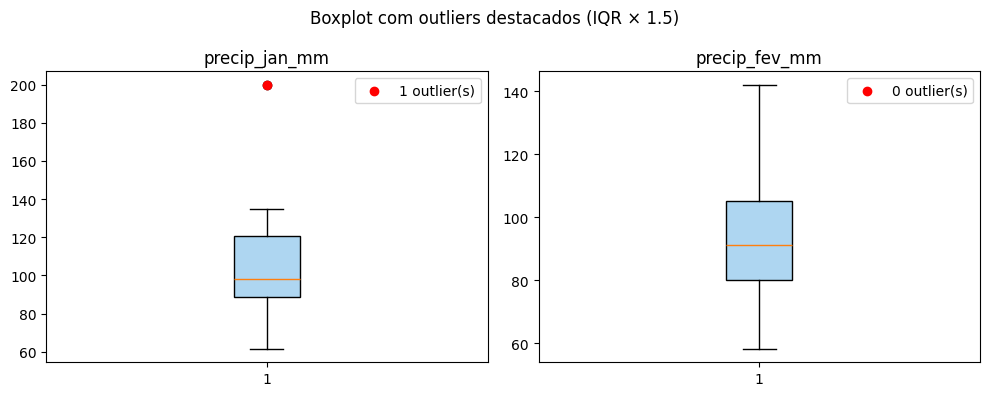

In [127]:
def detectar_outliers_iqr(serie):
    """Retorna máscara booleana com True onde há outlier pelo critério IQR."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, cols_precip):
    serie = df[col].dropna()
    outliers = detectar_outliers_iqr(serie)
    ax.boxplot(serie, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    ax.scatter(
        [1] * outliers.sum(),
        serie[outliers],
        color='red', zorder=5, label=f"{outliers.sum()} outlier(s)"
    )
    ax.set_title(col)
    ax.legend()

plt.suptitle("Boxplot com outliers destacados (IQR × 1.5)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Aplicar métodos de seleção de dados

Selecionar significa **reduzir o escopo** do dataset mantendo apenas o que é relevante para a análise. Há duas dimensões: **linhas** (registros) e **colunas** (atributos).

### 3.1 Seleção de registros (linhas)

| Critério | Quando usar |
|----------|-------------|
| Filtro por atributo | Remover registros inativos, fora da área de estudo |
| Filtro espacial | Selecionar feições dentro de um polígono ou buffer |
| Amostragem | Dataset muito grande; análise exploratória inicial |

In [128]:
# ── Seleção por atributo: apenas postos ativos ────────────────
df_ativos = df[df['ativo'] == True].copy()
print(f"Antes: {len(df)} registros | Após filtro 'ativo': {len(df_ativos)} registros")

# ── Seleção por domínio: coordenadas válidas ──────────────────
df_validos = df_ativos[
    (df_ativos['latitude'].abs()  <= 90) &
    (df_ativos['longitude'].abs() <= 180)
].copy()
print(f"Após filtro de coordenadas válidas: {len(df_validos)} registros")
df_validos[['id','nome','latitude','longitude']]

Antes: 10 registros | Após filtro 'ativo': 9 registros
Após filtro de coordenadas válidas: 8 registros


,id,nome,latitude,longitude
0,1,Posto A,-22.88,-43.10
1,2,Posto B,-22.90,-43.17
2,3,Posto C,-22.51,-43.18
3,4,Posto D,-23.01,-44.32
5,6,Posto F,-22.52,-44.08
8,9,Posto I,-22.47,-44.45
9,10,Posto J,-22.38,-41.79
10,11,Posto K,-22.88,-42.02


In [129]:
# ── Seleção espacial: postos dentro de um raio de 150 km do Rio de Janeiro
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df_validos,
    geometry=[Point(lon, lat) for lon, lat in
              zip(df_validos['longitude'], df_validos['latitude'])],
    crs='EPSG:4326'
).to_crs('EPSG:32723')  # Projeção métrica para medir distâncias

# Centro do Rio de Janeiro
centro_rj = gpd.GeoDataFrame(
    geometry=[Point(-43.17, -22.90)], crs='EPSG:4326'
).to_crs('EPSG:32723').geometry[0]

raio_m = 150_000  # 150 km
gdf_proximo = gdf[gdf.geometry.distance(centro_rj) <= raio_m].copy()

print(f"Postos a até 150 km do Rio de Janeiro: {len(gdf_proximo)}")
print(gdf_proximo[['id','nome','municipio']].to_string(index=False))

Postos a até 150 km do Rio de Janeiro: 7
 id    nome      municipio
  1 Posto A        Niterói
  2 Posto B Rio de Janeiro
  3 Posto C     Petrópolis
  4 Posto D Angra dos Reis
  6 Posto F  Volta Redonda
  9 Posto I        Resende
 11 Posto K      Cabo Frio


### 3.2 Seleção de atributos (colunas)

Manter apenas colunas relevantes reduz o ruído e melhora o desempenho dos modelos subsequentes.

In [130]:
# ── Padronização de strings ───────────────────────────────────
df_limpo = df_sem_dup.copy()

# Nome: Title Case + sem espaços extras
df_limpo['nome']       = df_limpo['nome'].str.strip().str.title()

# Município: strip + Title Case
df_limpo['municipio']  = df_limpo['municipio'].str.strip().str.title()

print("Nomes após padronização:")
print(df_limpo[['id','nome','municipio']])

Nomes após padronização:
    id     nome       municipio
0    1  Posto A         Niterói
1    2  Posto B  Rio De Janeiro
2    3  Posto C      Petrópolis
3    4  Posto D  Angra Dos Reis
5    6  Posto F   Volta Redonda
8    9  Posto I         Resende
9   10  Posto J           Macaé
10  11  Posto K       Cabo Frio


## 4. Aplicar métodos de completamento de dados

**Completamento** (ou *imputation*) é o processo de preencher valores ausentes com estimativas razoáveis. Há uma hierarquia de estratégias — da mais simples à mais sofisticada.

### 4.1 Estratégias de completamento

| Estratégia | Descrição | Quando usar |
|-----------|-----------|-------------|
| **Remoção** | Descarta linhas/colunas com NaN | % ausente alta, sem padrão espacial |
| **Média / Mediana** | Substitui pelo valor central da coluna | Distribuições simétricas / com outliers |
| **Moda** | Substitui pelo valor mais frequente | Variáveis categóricas |
| **Interpolação temporal** | Usa vizinhos no tempo | Séries temporais |
| **Interpolação espacial** | Usa vizinhos no espaço | Dados geoespaciais |
| **Modelo preditivo** | Treina um modelo para prever | Dados complexos com padrão |

### 4.2 Remoção de registros irrecuperáveis

In [131]:
print("NaNs antes do completamento:")
print(df_limpo.isnull().sum())

# Registros sem município E sem coordenadas válidas são irrecuperáveis
df_comp = df_limpo.dropna(subset=['latitude', 'longitude']).copy()
print(f"\nApós remover registros sem coordenadas: {len(df_comp)} registros")

NaNs antes do completamento:
id               0
nome             0
municipio        0
latitude         0
longitude        0
precip_jan_mm    1
precip_fev_mm    0
altitude_m       0
dtype: int64

Após remover registros sem coordenadas: 8 registros


### 4.3 Completamento de atributos categóricos (município)

In [132]:
# ── Municipio ausente: buscar via geocodificação reversa ──────
# Estratégia simples: usar a cidade mais próxima conhecida
# (em produção: usar uma API de geocodificação reversa)

print("Postos com município ausente:")
print(df_comp[df_comp['municipio'].isna()][['id','nome','latitude','longitude']])

# Simulando o resultado de uma geocodificação reversa
# (ex.: Nominatim / IBGE API de malhas)
municipios_recuperados = {
    # id: municipio inferido pelas coordenadas
    # (neste dataset sintético, o Posto G foi removido por coordenada inválida)
}

# Para campos categóricos sem regra clara, podemos usar 'Desconhecido'
df_comp['municipio'] = df_comp['municipio'].fillna('Desconhecido')
print("\nApós completamento de município:")
print(df_comp[['id','nome','municipio']])

Postos com município ausente:
Empty DataFrame
Columns: [id, nome, latitude, longitude]
Index: []

Após completamento de município:
    id     nome       municipio
0    1  Posto A         Niterói
1    2  Posto B  Rio De Janeiro
2    3  Posto C      Petrópolis
3    4  Posto D  Angra Dos Reis
5    6  Posto F   Volta Redonda
8    9  Posto I         Resende
9   10  Posto J           Macaé
10  11  Posto K       Cabo Frio


### 4.4 Completamento de atributos numéricos (precipitação)

Para variáveis contínuas com distribuição razoável, a **mediana** é mais robusta que a média na presença de outliers.

In [133]:
# ── Completamento por mediana da coluna ───────────────────────
for col in cols_precip:
    mediana = df_comp[col].median()
    n_antes = df_comp[col].isna().sum()
    df_comp[col] = df_comp[col].fillna(mediana)
    print(f"{col}: {n_antes} NaN(s) preenchido(s) com mediana = {mediana:.1f} mm")

print("\nNaNs após completamento numérico:")
print(df_comp[cols_precip].isnull().sum())

precip_jan_mm: 1 NaN(s) preenchido(s) com mediana = 98.3 mm
precip_fev_mm: 0 NaN(s) preenchido(s) com mediana = 91.4 mm

NaNs após completamento numérico:
precip_jan_mm    0
precip_fev_mm    0
dtype: int64


### 4.5 Completamento por interpolação espacial

Em dados geoespaciais, o princípio de **Tobler** — *"tudo está relacionado com tudo, mas coisas próximas mais do que coisas distantes"* — sugere que usar vizinhos espaciais é mais adequado que uma estatística global.

O método mais simples é o **Inverso da Distância Ponderada (IDW)**:

$$\hat{z}(p) = \frac{\sum_{i=1}^{n} \frac{z_i}{d_i^\beta}}{\sum_{i=1}^{n} \frac{1}{d_i^\beta}}$$

onde $d_i$ é a distância ao ponto $i$, e $\beta$ é o expoente de ponderação (tipicamente 2).

In [134]:
from scipy.spatial import cKDTree

def idw_completar(gdf, col, beta=2, n_vizinhos=3):
    """
    Completa NaNs de `col` usando IDW com os `n_vizinhos` mais próximos.
    `gdf` deve estar em projeção métrica (ex.: EPSG:32723).
    """
    gdf = gdf.copy()
    coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))

    mask_nan  = gdf[col].isna()
    mask_val  = ~mask_nan

    if mask_nan.sum() == 0:
        return gdf  # Nada a fazer

    # KD-tree apenas com pontos que têm valor
    tree = cKDTree(coords[mask_val])
    valores = gdf.loc[mask_val, col].values

    # Para cada ponto com NaN, buscar os n_vizinhos mais próximos
    dists, idxs = tree.query(coords[mask_nan], k=min(n_vizinhos, mask_val.sum()))

    # IDW
    pesos = 1.0 / (dists ** beta + 1e-10)  # Evita divisão por zero
    estimativas = np.sum(pesos * valores[idxs], axis=1) / np.sum(pesos, axis=1)

    gdf.loc[mask_nan, col] = estimativas.round(1)
    return gdf


# Criar GeoDataFrame para usar IDW
gdf_final = gpd.GeoDataFrame(
    df_comp,
    geometry=[Point(lon, lat) for lon, lat in
              zip(df_comp['longitude'], df_comp['latitude'])],
    crs='EPSG:4326'
).to_crs('EPSG:32723')

# Introduzindo um NaN artificial para demonstrar IDW
gdf_final.loc[gdf_final['id'] == 1, 'precip_jan_mm'] = np.nan
print("NaN introduzido no Posto 1 (Niterói):")
print(gdf_final[gdf_final['id']==1][['id','nome','precip_jan_mm']])

gdf_final = idw_completar(gdf_final, 'precip_jan_mm', beta=2, n_vizinhos=3)
print("\nApós IDW:")
print(gdf_final[gdf_final['id']==1][['id','nome','precip_jan_mm']])

NaN introduzido no Posto 1 (Niterói):
   id     nome  precip_jan_mm
0   1  Posto A            NaN

Após IDW:
   id     nome  precip_jan_mm
0   1  Posto A          133.6


### 4.6 Dataset final — visão consolidada

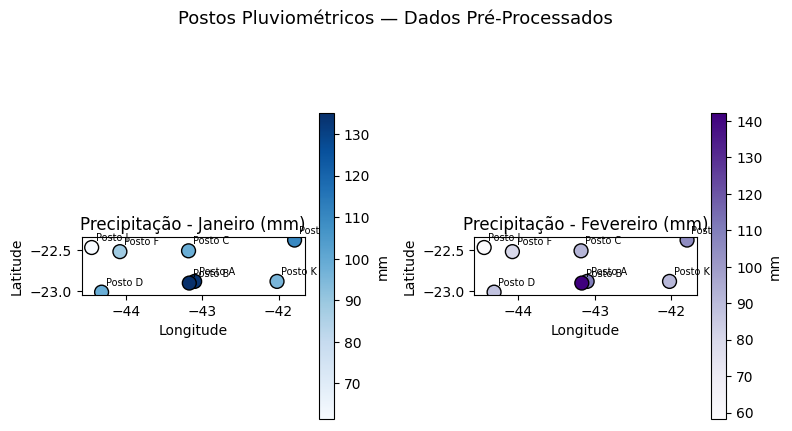


Dataset final:


,id,nome,municipio,precip_jan_mm,precip_fev_mm,altitude_m
0,1,Posto A,Niterói,133.6,110.2,15
1,2,Posto B,Rio De Janeiro,135.0,142.1,10
2,3,Posto C,Petrópolis,98.3,91.7,843
3,4,Posto D,Angra Dos Reis,98.3,88.0,5
5,6,Posto F,Volta Redonda,88.7,80.1,390
8,9,Posto I,Resende,61.4,58.2,430
9,10,Posto J,Macaé,110.2,105.3,12
10,11,Posto K,Cabo Frio,95.8,91.1,5


In [137]:
gdf_plot = gdf_final.to_crs('EPSG:4326')

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for ax, col, titulo, cor in zip(
    axes,
    ['precip_jan_mm', 'precip_fev_mm'],
    ['Precipitação - Janeiro (mm)', 'Precipitação - Fevereiro (mm)'],
    ['Blues', 'Purples']
):
    gdf_plot.plot(column=col, ax=ax, legend=True,
                  cmap=cor, markersize=100, edgecolor='black',
                  legend_kwds={'label': 'mm', 'shrink': 0.7})
    for _, row in gdf_plot.iterrows():
        ax.annotate(row['nome'], xy=(row.geometry.x, row.geometry.y),
                    xytext=(3, 5), textcoords='offset points', fontsize=7)
    ax.set_title(titulo)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle("Postos Pluviométricos — Dados Pré-Processados", fontsize=13)
plt.tight_layout()
plt.show()

print("\nDataset final:")
gdf_plot[['id','nome','municipio','precip_jan_mm','precip_fev_mm','altitude_m']]

## Complemento

### Resumo do pipeline de pré-processamento

```
Dados brutos
     │
     ▼
[1. DIAGNÓSTICO] ── isnull(), describe(), boxplot, mapa de ausentes
     │
     ▼
[2. SELEÇÃO] ─────── filtro por atributo, filtro espacial, seleção de colunas
     │
     ▼
[3. LIMPEZA] ─────── duplicatas, padronização, sentinelas, outliers
     │
     ▼
[4. COMPLETAMENTO] ─ remoção, mediana, interpolação espacial (IDW)
     │
     ▼
Dados prontos para Exploração
```

### Checklist de qualidade antes de avançar

- [ ] Nenhuma coluna essencial com NaN
- [ ] Coordenadas dentro dos limites válidos (`lat ∈ [-90, 90]`, `lon ∈ [-180, 180]`)
- [ ] CRS definido e consistente
- [ ] Sem duplicatas por identificador único
- [ ] Textos padronizados (sem variações de capitalização)
- [ ] Valores sentinela substituídos
- [ ] Outliers documentados (removidos ou justificados)
- [ ] Todas as decisões de tratamento registradas (rastreabilidade)

### Bibliotecas úteis

```python
# ydata-profiling: relatório automático de qualidade de dados
from ydata_profiling import ProfileReport
report = ProfileReport(df, title="Relatório de Qualidade")
report.to_notebook_iframe()

# missingno: visualização avançada de padrões de ausência
import missingno as msno
msno.matrix(df)
msno.heatmap(df)   # Correlação entre ausências

# pyproj / geopandas: reprojeção e validação de geometrias
gdf['valida'] = gdf.geometry.is_valid
gdf_corrigido = gdf.copy()
gdf_corrigido.geometry = gdf.geometry.buffer(0)  # Corrige geometrias inválidas
```

## Lista de exercícios complementares

**Exercício 1.** Carregue um CSV de sua escolha (sugestão: focos de queimadas do INPE). Use `describe()`, `isnull().sum()` e um boxplot para fazer o diagnóstico completo. Quantos e quais problemas você identificou?

**Exercício 2.** Dado o dataset de postos pluviométricos desta aula, adicione manualmente 3 novos problemas (um valor impossível, uma duplicata e um sentinela diferente). Aplique o pipeline completo de limpeza.

**Exercício 3.** Usando a malha municipal do IBGE e `geopandas`, selecione espacialmente todos os postos pluviométricos que caem dentro dos limites do estado do Rio de Janeiro. Quantos são descartados por cair fora?

**Exercício 4.** Compare três estratégias de completamento para a coluna `precip_jan_mm`: (a) média global, (b) mediana global, (c) IDW com 3 vizinhos. Para cada estratégia, calcule o erro absoluto médio em relação ao valor original que você ocultou.

**Exercício 5.** Pesquise e aplique a biblioteca `missingno` para visualizar os padrões de ausência do dataset. Os valores faltam de forma aleatória (*MCAR*) ou há um padrão espacial (*MNAR*)?

**Exercício 6 (desafio).** Monte um pipeline completo de pré-processamento usando `pandas` e `geopandas` encapsulado em uma classe Python `PreProcessadorGeoespacial`, com métodos: `.diagnosticar()`, `.selecionar()`, `.limpar()` e `.completar()`. O método `.diagnosticar()` deve retornar um relatório em formato de dicionário.